# Analysis Notebook

Combined analysis notebook:

1. Controlled bb144 FastSA Stage-2 benchmark.
2. Batch runs for `bb144_n_fastsa_k1000.json` (`--log`), `bb144_n_init.json`, and all `Scheduler_Test/INPUT/*.json` using both `naive_dag` and `naive_n_dag`.


In [8]:
from copy import deepcopy
from pathlib import Path
import json
import re
import time
import sys
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve()
src_dir = repo_root / "src"
if src_dir.exists() and str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from naive_dag.main import load_config as load_naive_dag_config
from naive_dag.main import main as naive_dag_main
from naive_n_dag.main import load_config as load_naive_n_dag_config
from naive_n_dag.main import main as naive_n_dag_main

outputs_dir = repo_root / "outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)

bb144_qasm = repo_root / "inputs" / "qasm_files" / "bb144_bivariate_bicycle_cz.qasm"
assert bb144_qasm.exists(), f"Missing QASM file: {bb144_qasm}"


def timed_run(fn, *args, **kwargs):
    t0 = time.perf_counter()
    exit_code = fn(*args, **kwargs)
    dt = time.perf_counter() - t0
    return exit_code, dt


def run_naive_dag_with_named_output(config_path: Path, qasm_path: Path, out_dir: Path, output_name: str, seed: int = 0):
    out_dir.mkdir(parents=True, exist_ok=True)
    config = load_naive_dag_config(config_path)
    exit_code, dt = timed_run(
        naive_dag_main,
        config,
        str(qasm_path),
        schedule_output_dir=out_dir,
        config_path=config_path,
        quiet=True,
        seed=seed,
    )
    produced = out_dir / f"{qasm_path.stem}.schedule.txt"
    target = out_dir / output_name
    if produced.exists():
        if target.exists():
            target.unlink()
        produced.rename(target)
    return exit_code, dt, target


def run_naive_n_dag_with_named_output(config_path: Path, qasm_path: Path, out_dir: Path, output_name: str, seed: int = 0, log: bool = False):
    out_dir.mkdir(parents=True, exist_ok=True)
    config = load_naive_n_dag_config(config_path)
    exit_code, dt = timed_run(
        naive_n_dag_main,
        config,
        str(qasm_path),
        schedule_output_dir=out_dir,
        config_path=config_path,
        quiet=True,
        seed=seed,
        output_name=output_name,
        log=log,
    )
    target = out_dir / output_name
    return exit_code, dt, target


def resolve_qasm_for_config(config_path: Path) -> Path:
    cfg = json.loads(config_path.read_text())

    if config_path.name.startswith("bb144_n_"):
        return bb144_qasm

    base_key = "qasm_base_dir" if "qasm_base_dir" in cfg else "qasm_dir"
    base_dir = (config_path.parent / cfg[base_key]).resolve()
    stem = config_path.stem

    candidates = [
        base_dir / f"{stem}.qasm",
        base_dir / f"{stem}_transpiled.qasm",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate

    hits = sorted(base_dir.glob(f"{stem}*.qasm"))
    if hits:
        return hits[0]

    raise FileNotFoundError(f"Could not resolve qasm for {config_path} from base_dir={base_dir}")


## 1) Controlled bb144 Stage-2 sweep (`k = stage2_iterations`)

Only `Fastsa_fill.stage2_iterations` changes. All other parameters remain fixed.


In [39]:
benchmark_out = outputs_dir / "fastsa_stage2_controlled"
benchmark_out.mkdir(parents=True, exist_ok=True)

base_config_path = repo_root / "inputs" / "algorithms" / "bb144_n_fastsa_k7.json"
qasm_path = bb144_qasm

assert base_config_path.exists(), f"Missing base config: {base_config_path}"

base_config = json.loads(base_config_path.read_text())
print("base_config:", base_config_path)
print("qasm:", qasm_path)

stage2_values = [0, 1, 2, 3, 5, 7, 10, 20, 50, 100, 1000]
seeds = [0] 

fixed_fastsa = {
    "stage1_iterations": int(base_config.get("Fastsa_fill", {}).get("stage1_iterations", 2)),
    "c": float(base_config.get("Fastsa_fill", {}).get("c", 100)),
    "initial_accept_prob": float(base_config.get("Fastsa_fill", {}).get("initial_accept_prob", 0.99)),
    "stage3_temperature_threshold": float(base_config.get("Fastsa_fill", {}).get("stage3_temperature_threshold", 1e-4)),
    "stage3_max_iterations": int(base_config.get("Fastsa_fill", {}).get("stage3_max_iterations", 0)),
    "stage3_section_size": int(base_config.get("Fastsa_fill", {}).get("stage3_section_size", 3)),
}

print("fixed_fastsa:", fixed_fastsa)
print("stage2_values:", stage2_values)
print("seeds:", seeds)


base_config: /home/gage/Quantum_Class/Phys765/inputs/algorithms/bb144_n_fastsa_k7.json
qasm: /home/gage/Quantum_Class/Phys765/inputs/qasm_files/bb144_bivariate_bicycle_cz.qasm
fixed_fastsa: {'stage1_iterations': 2, 'c': 100.0, 'initial_accept_prob': 0.99, 'stage3_temperature_threshold': 0.0001, 'stage3_max_iterations': 0, 'stage3_section_size': 3}
stage2_values: [0, 1, 2, 3, 5, 7, 10, 20, 50, 100, 1000]
seeds: [0]


In [40]:
final_time_re = re.compile(r"^final_time:\s*([0-9eE+\-.]+)\s+microsecond")


def parse_final_time_microseconds(schedule_path: Path) -> float:
    for line in schedule_path.read_text(encoding="utf-8").splitlines():
        m = final_time_re.match(line.strip())
        if m:
            return float(m.group(1))
    raise ValueError(f"final_time not found in {schedule_path}")


def run_one(stage2_iterations: int, seed: int) -> dict:
    cfg = deepcopy(base_config)
    cfg["Fastsa_fill"] = dict(fixed_fastsa)
    cfg["Fastsa_fill"]["stage2_iterations"] = int(stage2_iterations)

    run_tag = f"bb144_controlled_k{stage2_iterations}_seed{seed}"
    output_name = f"{run_tag}.schedule.txt"

    t0 = time.perf_counter()
    exit_code = naive_n_dag_main(
        cfg,
        str(qasm_path),
        schedule_output_dir=benchmark_out,
        config_path=base_config_path,
        quiet=True,
        seed=seed,
        output_name=output_name,
        log=True,
    )
    wall_seconds = time.perf_counter() - t0

    schedule_path = benchmark_out / output_name
    log_path = benchmark_out / f"{run_tag}.fastsa_log.csv"

    final_time_us = parse_final_time_microseconds(schedule_path)
    log_df = pd.read_csv(log_path)

    return {
        "k": stage2_iterations,
        "seed": seed,
        "exit_code": exit_code,
        "wall_seconds": wall_seconds,
        "final_time_us": final_time_us,
        "best_cost_min": float(log_df["best_cost"].min()),
        "best_cost_last": float(log_df["best_cost"].iloc[-1]),
        "log_steps": int(len(log_df)),
        "schedule_file": str(schedule_path.relative_to(repo_root)),
        "log_file": str(log_path.relative_to(repo_root)),
    }


records = []
for k in stage2_values:
    for seed in seeds:
        rec = run_one(k, seed)
        records.append(rec)
        print(f"k={k:>4} seed={seed} final_time_us={rec['final_time_us']:.3f} best_cost_min={rec['best_cost_min']:.6f}")

results_df = pd.DataFrame(records).sort_values(["k", "seed"]).reset_index(drop=True)
summary_df = (
    results_df.groupby("k", as_index=False)
    .agg(
        final_time_us_mean=("final_time_us", "mean"),
        best_cost_min_mean=("best_cost_min", "mean"),
        wall_seconds_mean=("wall_seconds", "mean"),
    )
    .sort_values("k")
    .reset_index(drop=True)
)
results_df


k=   0 seed=0 final_time_us=240288.495 best_cost_min=16.538996
k=   1 seed=0 final_time_us=240288.495 best_cost_min=16.538996
k=   2 seed=0 final_time_us=240288.495 best_cost_min=16.538996
k=   3 seed=0 final_time_us=216065.303 best_cost_min=16.338955
k=   5 seed=0 final_time_us=216065.303 best_cost_min=16.338955
k=   7 seed=0 final_time_us=216065.303 best_cost_min=16.338955
k=  10 seed=0 final_time_us=218560.494 best_cost_min=16.215480
k=  20 seed=0 final_time_us=218560.494 best_cost_min=16.215480
k=  50 seed=0 final_time_us=215234.532 best_cost_min=14.898437
k= 100 seed=0 final_time_us=215228.201 best_cost_min=14.680362
k=1000 seed=0 final_time_us=215228.201 best_cost_min=14.680362


,k,seed,exit_code,wall_seconds,final_time_us,best_cost_min,best_cost_last,log_steps,schedule_file,log_file
0,0,0,0,0.770244,240288.494738,16.538996,16.538996,3,outputs/fastsa_stage2_controlled/bb144_control...,outputs/fastsa_stage2_controlled/bb144_control...
1,1,0,0,0.783990,240288.494738,16.538996,16.538996,4,outputs/fastsa_stage2_controlled/bb144_control...,outputs/fastsa_stage2_controlled/bb144_control...
2,2,0,0,0.728794,240288.494738,16.538996,16.538996,5,outputs/fastsa_stage2_controlled/bb144_control...,outputs/fastsa_stage2_controlled/bb144_control...
3,3,0,0,0.745417,216065.303453,16.338955,16.338955,6,outputs/fastsa_stage2_controlled/bb144_control...,outputs/fastsa_stage2_controlled/bb144_control...
4,5,0,0,0.777293,216065.303453,16.338955,16.338955,8,outputs/fastsa_stage2_controlled/bb144_control...,outputs/fastsa_stage2_controlled/bb144_control...
5,7,0,0,0.808433,216065.303453,16.338955,16.338955,10,outputs/fastsa_stage2_controlled/bb144_control...,outputs/fastsa_stage2_controlled/bb144_control...
6,10,0,0,0.895308,218560.494320,16.215480,16.215480,13,outputs/fastsa_stage2_controlled/bb144_control...,outputs/fastsa_stage2_controlled/bb144_control...
7,20,0,0,1.069001,218560.494320,16.215480,16.215480,23,outputs/fastsa_stage2_controlled/bb144_control...,outputs/fastsa_stage2_controlled/bb144_control...
8,50,0,0,1.503153,215234.532274,14.898437,14.898437,53,outputs/fastsa_stage2_controlled/bb144_control...,outputs/fastsa_stage2_controlled/bb144_control...
9,100,0,0,2.400563,215228.201368,14.680362,14.680362,103,outputs/fastsa_stage2_controlled/bb144_control...,outputs/fastsa_stage2_controlled/bb144_control...


`k` is the number of greedy Stage-2 iterations. The next cell we plot both FastSA objective and schedule time.


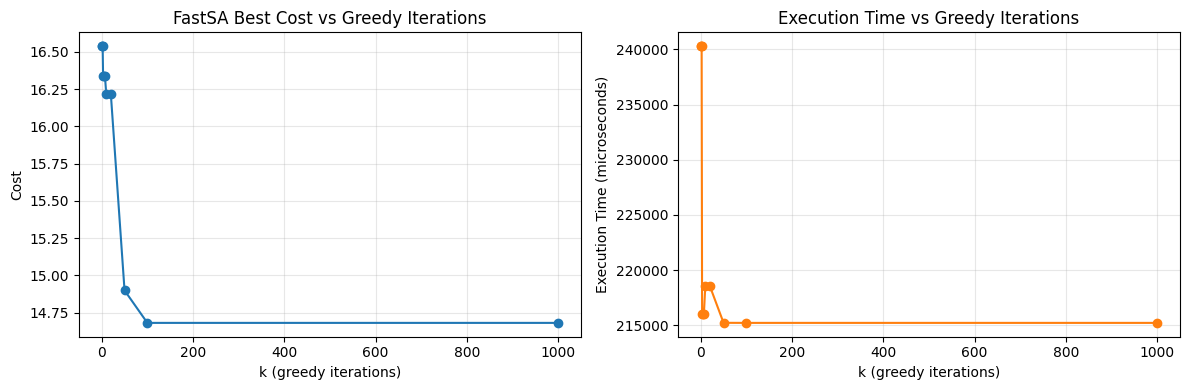

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(summary_df["k"], summary_df["best_cost_min_mean"], marker="o")
axes[0].set_title("FastSA Best Cost vs Greedy Iterations")
axes[0].set_xlabel("k (greedy iterations)")
axes[0].set_ylabel("Cost")
axes[0].grid(alpha=0.3)

axes[1].plot(summary_df["k"], summary_df["final_time_us_mean"], marker="o", color="tab:orange")
axes[1].set_title("Execution Time vs Greedy Iterations")
axes[1].set_xlabel("k (greedy iterations)")
axes[1].set_ylabel("Execution Time (microseconds)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 2) Batch run: `bb144_n_fastsa_k1000.json` (`--log`), `bb144_n_init.json`, and all `Scheduler_Test/INPUT/*.json`

This block runs both `naive_dag` and `naive_n_dag` inline and writes outputs to `Scheduler_Test/OUTPUT/`.


In [ ]:
scheduler_output_dir = repo_root / "Scheduler_Test" / "OUTPUT"
scheduler_output_dir.mkdir(parents=True, exist_ok=True)

batch_configs = [
    repo_root / "inputs" / "algorithms" / "bb144_n_fastsa_k1000.json",
    repo_root / "inputs" / "algorithms" / "bb144_n_init.json",
]

batch_records = []
for cfg_path in batch_configs:
    qasm_path = resolve_qasm_for_config(cfg_path)

    run_log = cfg_path.name == "bb144_n_fastsa_k1000.json"

    n_output_name = f"{cfg_path.stem}.naive_n_dag.schedule.txt"
    n_exit, n_sec, n_path = run_naive_n_dag_with_named_output(
        cfg_path,
        qasm_path,
        scheduler_output_dir,
        n_output_name,
        seed=0,
        log=run_log,
    )
    batch_records.append(
        {
            "config": str(cfg_path.relative_to(repo_root)),
            "solver": "naive_n_dag",
            "qasm": str(qasm_path.relative_to(repo_root)),
            "wall_seconds": n_sec,
            "exit_code": n_exit,
            "output_file": str(n_path.relative_to(repo_root)),
            "log_enabled": run_log,
        }
    )

    d_output_name = f"{cfg_path.stem}.naive_dag.schedule.txt"
    d_exit, d_sec, d_path = run_naive_dag_with_named_output(
        cfg_path,
        qasm_path,
        scheduler_output_dir,
        d_output_name,
        seed=0,
    )
    batch_records.append(
        {
            "config": str(cfg_path.relative_to(repo_root)),
            "solver": "naive_dag",
            "qasm": str(qasm_path.relative_to(repo_root)),
            "wall_seconds": d_sec,
            "exit_code": d_exit,
            "output_file": str(d_path.relative_to(repo_root)),
            "log_enabled": False,
        }
    )

batch_df = pd.DataFrame(batch_records).sort_values(["config", "solver"]).reset_index(drop=True)
batch_df


562868.6664511404 microsecond
schedule_file=/home/gage/Quantum_Class/Phys765/Scheduler_Test/OUTPUT/bb144_bivariate_bicycle_cz.schedule.txt
729842.8397114532 microsecond
schedule_file=/home/gage/Quantum_Class/Phys765/Scheduler_Test/OUTPUT/bb144_bivariate_bicycle_cz.schedule.txt
3785.1474240696093 microsecond
schedule_file=/home/gage/Quantum_Class/Phys765/Scheduler_Test/OUTPUT/bv_n14.schedule.txt
9504.689921499996 microsecond
schedule_file=/home/gage/Quantum_Class/Phys765/Scheduler_Test/OUTPUT/bv_n50.schedule.txt
16670.11635766899 microsecond
schedule_file=/home/gage/Quantum_Class/Phys765/Scheduler_Test/OUTPUT/bv_n70.schedule.txt
125422.96563909475 microsecond
schedule_file=/home/gage/Quantum_Class/Phys765/Scheduler_Test/OUTPUT/qft_n18_transpiled.schedule.txt
371220.52958314307 microsecond
schedule_file=/home/gage/Quantum_Class/Phys765/Scheduler_Test/OUTPUT/qft_n29_transpiled.schedule.txt
4438.706464040282 microsecond
schedule_file=/home/gage/Quantum_Class/Phys765/Scheduler_Test/OUTPUT/v

,config,solver,qasm,wall_seconds,exit_code,output_file,log_enabled
0,Scheduler_Test/INPUT/bv_n14.json,naive_dag,Scheduler_Test/bv/bv_n14.qasm,0.005961,0,Scheduler_Test/OUTPUT/bv_n14.naive_dag.schedul...,False
1,Scheduler_Test/INPUT/bv_n14.json,naive_n_dag,Scheduler_Test/bv/bv_n14.qasm,77.905309,0,Scheduler_Test/OUTPUT/bv_n14.naive_n_dag.sched...,False
2,Scheduler_Test/INPUT/bv_n50.json,naive_dag,Scheduler_Test/bv/bv_n50.qasm,0.009914,0,Scheduler_Test/OUTPUT/bv_n50.naive_dag.schedul...,False
3,Scheduler_Test/INPUT/bv_n50.json,naive_n_dag,Scheduler_Test/bv/bv_n50.qasm,102.395184,0,Scheduler_Test/OUTPUT/bv_n50.naive_n_dag.sched...,False
4,Scheduler_Test/INPUT/bv_n70.json,naive_dag,Scheduler_Test/bv/bv_n70.qasm,0.016342,0,Scheduler_Test/OUTPUT/bv_n70.naive_dag.schedul...,False
5,Scheduler_Test/INPUT/bv_n70.json,naive_n_dag,Scheduler_Test/bv/bv_n70.qasm,191.240498,0,Scheduler_Test/OUTPUT/bv_n70.naive_n_dag.sched...,False
6,Scheduler_Test/INPUT/qft_n18.json,naive_dag,inputs/qasm_files/qft_n18_transpiled.qasm,0.097587,0,Scheduler_Test/OUTPUT/qft_n18.naive_dag.schedu...,False
7,Scheduler_Test/INPUT/qft_n18.json,naive_n_dag,inputs/qasm_files/qft_n18_transpiled.qasm,339.491057,0,Scheduler_Test/OUTPUT/qft_n18.naive_n_dag.sche...,False
8,Scheduler_Test/INPUT/qft_n29.json,naive_dag,inputs/qasm_files/qft_n29_transpiled.qasm,0.252720,0,Scheduler_Test/OUTPUT/qft_n29.naive_dag.schedu...,False
9,Scheduler_Test/INPUT/qft_n29.json,naive_n_dag,inputs/qasm_files/qft_n29_transpiled.qasm,987.770320,0,Scheduler_Test/OUTPUT/qft_n29.naive_n_dag.sche...,False


This block runs both `naive_dag` and `naive_n_dag` inline and writes outputs to `Scheduler_Test/OUTPUT/`.

In [29]:
scheduler_output_dir = repo_root / "Scheduler_Test" / "OUTPUT"
scheduler_output_dir.mkdir(parents=True, exist_ok=True)

batch_configs = []
batch_configs.extend(sorted((repo_root / "Scheduler_Test" / "INPUT").glob("*.json")))

batch_records = []
for cfg_path in batch_configs:
    qasm_path = resolve_qasm_for_config(cfg_path)

    n_output_name = f"{cfg_path.stem}.naive_n_dag.schedule.txt"
    n_exit, n_sec, n_path = run_naive_n_dag_with_named_output(
        cfg_path,
        qasm_path,
        scheduler_output_dir,
        n_output_name,
        seed=0,
    )
    batch_records.append(
        {
            "config": str(cfg_path.relative_to(repo_root)),
            "solver": "naive_n_dag",
            "qasm": str(qasm_path.relative_to(repo_root)),
            "wall_seconds": n_sec,
            "exit_code": n_exit,
            "output_file": str(n_path.relative_to(repo_root)),
            "log_enabled": False,
        }
    )

    d_output_name = f"{cfg_path.stem}.naive_dag.schedule.txt"
    d_exit, d_sec, d_path = run_naive_dag_with_named_output(
        cfg_path,
        qasm_path,
        scheduler_output_dir,
        d_output_name,
        seed=0,
    )
    batch_records.append(
        {
            "config": str(cfg_path.relative_to(repo_root)),
            "solver": "naive_dag",
            "qasm": str(qasm_path.relative_to(repo_root)),
            "wall_seconds": d_sec,
            "exit_code": d_exit,
            "output_file": str(d_path.relative_to(repo_root)),
            "log_enabled": False,
        }
    )

batch_df = pd.DataFrame(batch_records).sort_values(["config", "solver"]).reset_index(drop=True)
batch_df


3785.1474240696093 microsecond
schedule_file=/home/gage/Quantum_Class/Phys765/Scheduler_Test/OUTPUT/bv_n14.schedule.txt
9504.689921499996 microsecond
schedule_file=/home/gage/Quantum_Class/Phys765/Scheduler_Test/OUTPUT/bv_n50.schedule.txt
16670.11635766899 microsecond
schedule_file=/home/gage/Quantum_Class/Phys765/Scheduler_Test/OUTPUT/bv_n70.schedule.txt
125422.96563909475 microsecond
schedule_file=/home/gage/Quantum_Class/Phys765/Scheduler_Test/OUTPUT/qft_n18_transpiled.schedule.txt
371220.52958314307 microsecond
schedule_file=/home/gage/Quantum_Class/Phys765/Scheduler_Test/OUTPUT/qft_n29_transpiled.schedule.txt
19578.199009112683 microsecond
schedule_file=/home/gage/Quantum_Class/Phys765/Scheduler_Test/OUTPUT/vqe_n30.schedule.txt
36699.635959360516 microsecond
schedule_file=/home/gage/Quantum_Class/Phys765/Scheduler_Test/OUTPUT/vqe_n50.schedule.txt


,config,solver,qasm,wall_seconds,exit_code,output_file,log_enabled
0,Scheduler_Test/INPUT/bv_n14.json,naive_dag,Scheduler_Test/bv/bv_n14.qasm,0.006953,0,Scheduler_Test/OUTPUT/bv_n14.naive_dag.schedul...,False
1,Scheduler_Test/INPUT/bv_n14.json,naive_n_dag,Scheduler_Test/bv/bv_n14.qasm,83.804646,0,Scheduler_Test/OUTPUT/bv_n14.naive_n_dag.sched...,False
2,Scheduler_Test/INPUT/bv_n50.json,naive_dag,Scheduler_Test/bv/bv_n50.qasm,0.010525,0,Scheduler_Test/OUTPUT/bv_n50.naive_dag.schedul...,False
3,Scheduler_Test/INPUT/bv_n50.json,naive_n_dag,Scheduler_Test/bv/bv_n50.qasm,106.210922,0,Scheduler_Test/OUTPUT/bv_n50.naive_n_dag.sched...,False
4,Scheduler_Test/INPUT/bv_n70.json,naive_dag,Scheduler_Test/bv/bv_n70.qasm,0.018803,0,Scheduler_Test/OUTPUT/bv_n70.naive_dag.schedul...,False
5,Scheduler_Test/INPUT/bv_n70.json,naive_n_dag,Scheduler_Test/bv/bv_n70.qasm,199.048110,0,Scheduler_Test/OUTPUT/bv_n70.naive_n_dag.sched...,False
6,Scheduler_Test/INPUT/qft_n18.json,naive_dag,inputs/qasm_files/qft_n18_transpiled.qasm,0.093978,0,Scheduler_Test/OUTPUT/qft_n18.naive_dag.schedu...,False
7,Scheduler_Test/INPUT/qft_n18.json,naive_n_dag,inputs/qasm_files/qft_n18_transpiled.qasm,348.184521,0,Scheduler_Test/OUTPUT/qft_n18.naive_n_dag.sche...,False
8,Scheduler_Test/INPUT/qft_n29.json,naive_dag,inputs/qasm_files/qft_n29_transpiled.qasm,0.261271,0,Scheduler_Test/OUTPUT/qft_n29.naive_dag.schedu...,False
9,Scheduler_Test/INPUT/qft_n29.json,naive_n_dag,inputs/qasm_files/qft_n29_transpiled.qasm,1037.134964,0,Scheduler_Test/OUTPUT/qft_n29.naive_n_dag.sche...,False


## 3) Plot FastSA log for `bb144_n_fastsa_k1000`

This reuses `plot_fastsa_csv` from `test.ipynb` and plots the log generated by the bb144 k1000 run.


In [21]:
import csv
import numpy as np
import matplotlib.pyplot as plt


def plot_fastsa_csv(filepath):
    steps = []
    best_costs = []
    temperatures = []

    # Read CSV
    with open(filepath, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            steps.append(int(row["step"]))
            best_costs.append(float(row["best_cost"]))
            temperatures.append(float(row["temperature"]))

    # Plot temperature vs step
    plt.figure()
    plt.plot(steps[2:], temperatures[2:])
    plt.xlabel("Step")
    plt.ylabel("Temperature")
    plt.title("Temperature vs Step")
    plt.show()

    # Plot best_cost vs step
    plt.figure()
    plt.plot(steps[2:], best_costs[2:])
    plt.xlabel("Step")
    plt.ylabel("Best Cost")
    plt.title("Best Cost vs Step")
    plt.show()

    exp_invT = [min(1.0, np.exp(-1.0 / temp)) for temp in temperatures[2:] if temp != 0]
    plt.figure()
    plt.plot(steps[2:2 + len(exp_invT)], exp_invT)
    plt.xlabel("Step")
    plt.ylabel(r"$\exp(1/T)$")
    plt.title(r"$\exp(1/T)$ vs Step")
    plt.show()


Using log: /home/gage/Quantum_Class/Phys765/Scheduler_Test/OUTPUT/bb144_n_fastsa_k1000.naive_n_dag.fastsa_log.csv


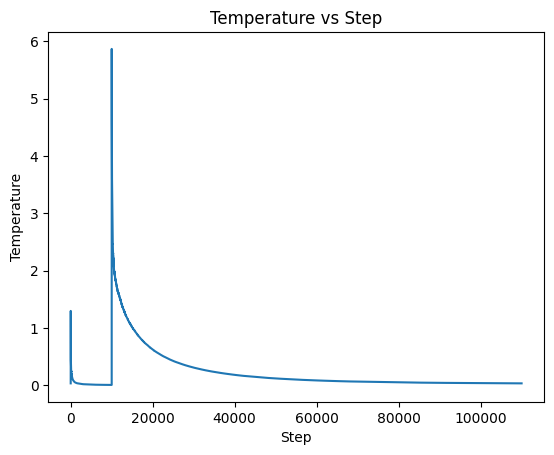

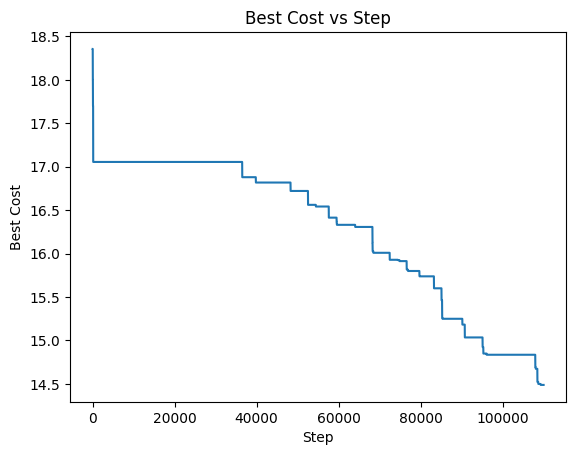

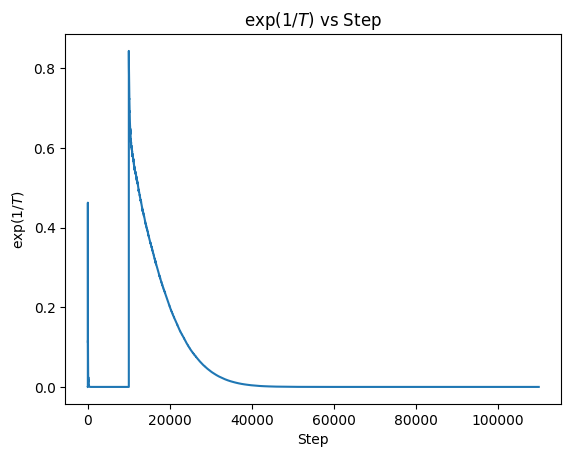

In [22]:
candidate_logs = [
    repo_root / "Scheduler_Test" / "OUTPUT" / "bb144_n_fastsa_k1000.naive_n_dag.fastsa_log.csv",
    repo_root / "outputs" / "bb144_n_fastsa_k1000.fastsa_log.csv",
]

log_path = None
for p in candidate_logs:
    if p.exists():
        log_path = p
        break

if log_path is None:
    raise FileNotFoundError(
        "Could not find bb144_n_fastsa_k1000 fastsa log. Run the bb144 batch cell first."
    )

print("Using log:", log_path)
plot_fastsa_csv(str(log_path))


## 4) `scheduler_batch_timings.csv` Bar Graphs

This uses the same plotting workflow from `test.ipynb` and does not modify the CSV.


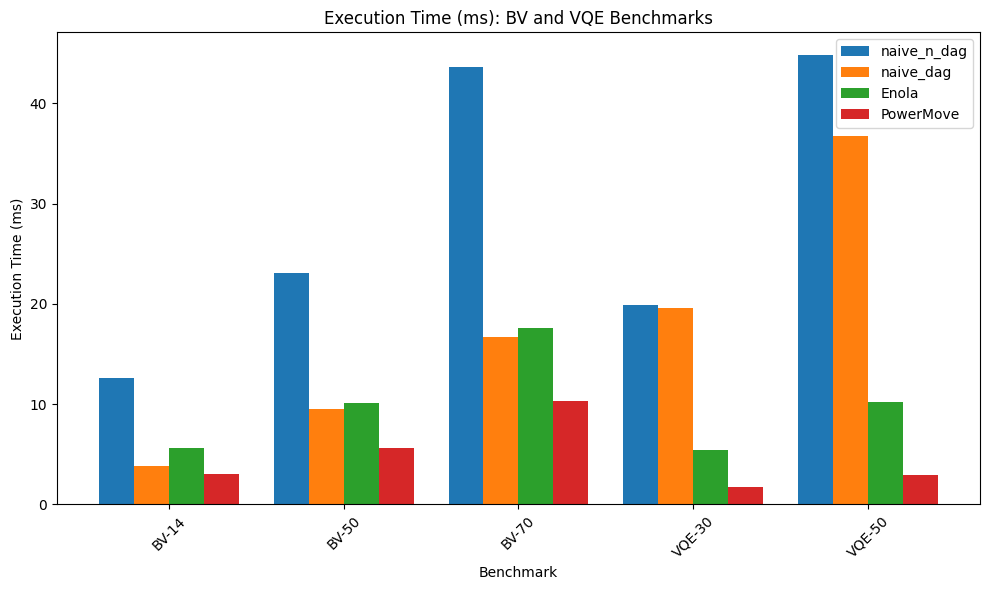

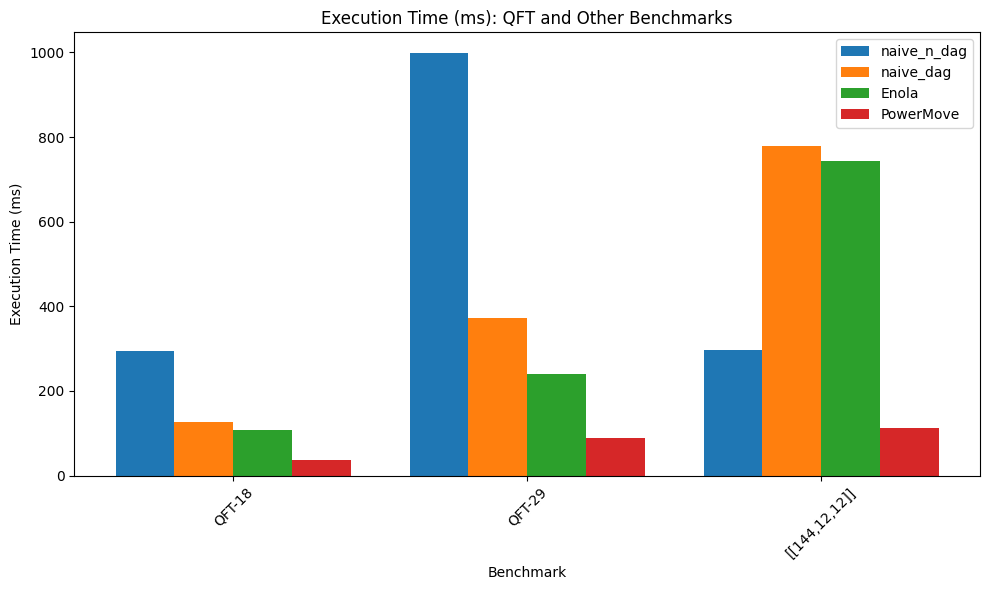

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load CSV with proper encoding
df = pd.read_csv("scheduler_batch_timings.csv", encoding="latin-1")

# Clean column names
df.columns = df.columns.str.strip()

# Rename column
df = df.rename(columns={"Texec (µs)": "Texec_us"})

# Convert to milliseconds
df["Texec_ms"] = df["Texec_us"] / 1000.0

# Keep only relevant solvers
solvers = ["naive_n_dag", "naive_dag", "Enola", "PowerMove"]
df = df[df["solver"].isin(solvers)]

# -------- Split benchmarks --------
group1 = ["BV-14", "BV-50", "BV-70", "VQE-30", "VQE-50"]
group2 = [b for b in df["Benchmark"].dropna().unique() if b not in group1]


def plot_group(benchmarks, title):
    data = {solver: [] for solver in solvers}

    for bench in benchmarks:
        subset = df[df["Benchmark"] == bench]
        for solver in solvers:
            row = subset[subset["solver"] == solver]
            if not row.empty:
                data[solver].append(row["Texec_ms"].values[0])
            else:
                data[solver].append(0)

    x = np.arange(len(benchmarks))
    width = 0.2

    plt.figure(figsize=(10, 6))

    for i, solver in enumerate(solvers):
        plt.bar(x + i * width, data[solver], width, label=solver)

    plt.xlabel("Benchmark")
    plt.ylabel("Execution Time (ms)")
    plt.title(title)
    plt.xticks(x + width * 1.5, benchmarks, rotation=45)
    plt.legend()

    plt.tight_layout()
    plt.show()


# -------- Plot 1 --------
plot_group(group1, "Execution Time (ms): BV and VQE Benchmarks")

# -------- Plot 2 --------
plot_group(group2, "Execution Time (ms): QFT and Other Benchmarks")


## 5) `scheduler_batch_timings.csv` Summary Table


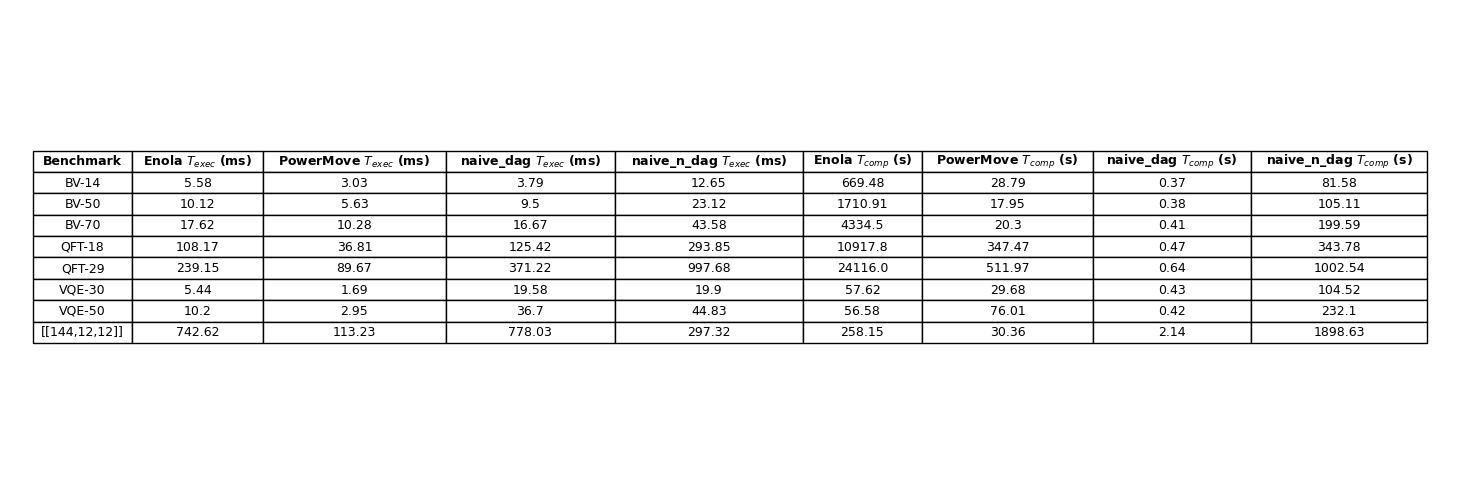

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV with encoding fix
df = pd.read_csv("scheduler_batch_timings.csv", encoding="latin-1")

# Clean column names
df.columns = df.columns.str.strip()

# Rename columns
df = df.rename(columns={
    "Texec (µs)": "Texec_us",
    "Tcomp (s)": "Tcomp_s"
})

# Convert µs -> ms
df["Texec_ms"] = df["Texec_us"] / 1000.0

# Keep only relevant solvers
solvers = ["naive_n_dag", "naive_dag", "Enola", "PowerMove"]
df = df[df["solver"].isin(solvers)]

# -------- Pivot Table --------
pivot_df = df.pivot(index="Benchmark", columns="solver", values=["Texec_ms", "Tcomp_s"])

# Flatten columns and apply subscript formatting
pivot_df.columns = [
    f"{solver} " + (r"$T_{exec}$ (ms)" if metric == "Texec_ms" else r"$T_{comp}$ (s)")
    for metric, solver in pivot_df.columns
]

# Reset index so Benchmark is a column
pivot_df = pivot_df.reset_index()

# Round values
pivot_df = pivot_df.round(2)

# -------- Plot Table --------
fig, ax = plt.subplots(figsize=(16, len(pivot_df) * 0.6))
ax.axis('off')

table = ax.table(
    cellText=pivot_df.values,
    colLabels=pivot_df.columns,
    loc='center',
    cellLoc='center'
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(9)
table.auto_set_column_width(col=list(range(len(pivot_df.columns))))

# Bold header row
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')

plt.tight_layout(pad=0.2)
plt.show()



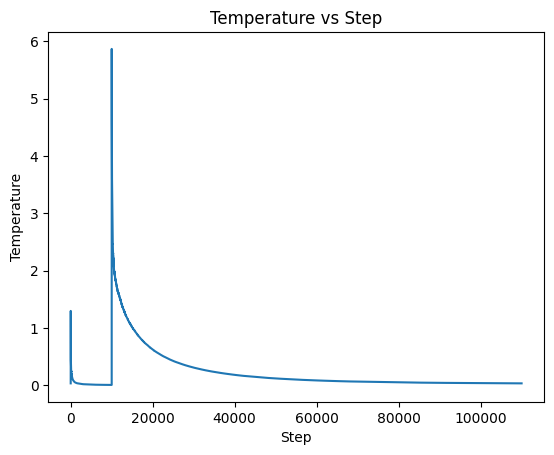

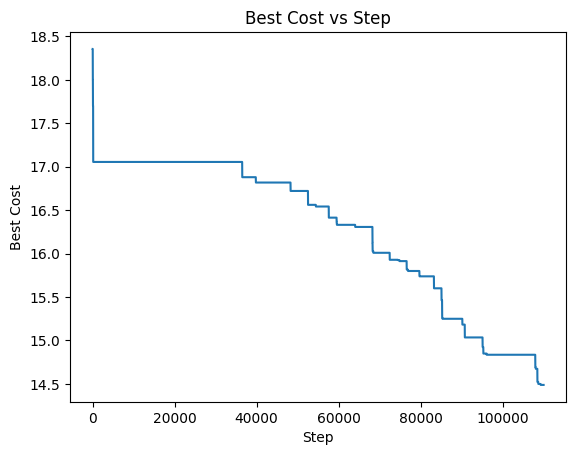

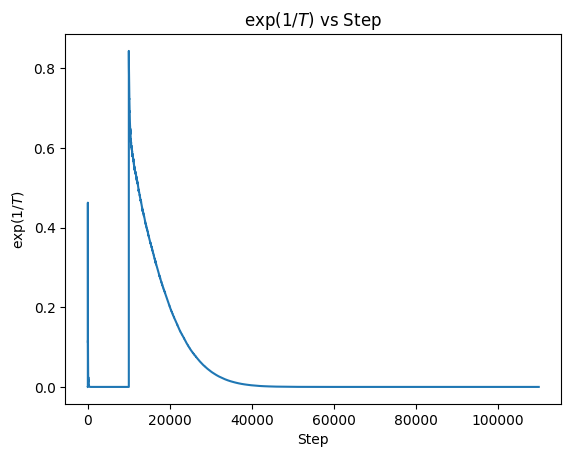

In [33]:
plot_fastsa_csv("outputs/bb144_n_fastsa_k1000.fastsa_log.csv")
